# Verify preprocessing

For a handful of sample rows (spanning different classes), show: original image, mask overlay, cropped region, and the final illumination-normalized output (cropped resolution, unresized — resizing to a target size happens later as a tensor transform in `src/dataset.py`, not in the cached files). Use this to sanity-check `CROP_PADDING_FRAC` and the gray-world colour correction as real `BM/` masks are added or updated.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import cv2
import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.preprocessing import crop_to_mask, gray_world_lab_normalize, load_image, load_mask

In [2]:
annotations = pd.read_csv(config.ANNOTATIONS_RAW)
sample = pd.concat(
    [annotations[annotations["class"] == c].sample(1, random_state=0) for c in config.CLASSES]
).reset_index(drop=True)
sample

,class,sub_class,partition,celeba,path_rgb_original,path_rgb_masked,path_mask
0,autunno,soft,train,True,RGB/train/autunno/soft/18194.jpg,RGB-M/train/autunno/soft/18194.png,BM/train/autunno/soft/18194.png
1,estate,soft,train,False,RGB/train/estate/soft/images-166.png,RGB-M/train/estate/soft/images-166.png,BM/train/estate/soft/images-166.png
2,inverno,cool,train,True,RGB/train/inverno/cool/14476.jpg,RGB-M/train/inverno/cool/14476.png,BM/train/inverno/cool/14476.png
3,primavera,warm,test,True,RGB/test/primavera/warm/25306.jpg,RGB-M/test/primavera/warm/25306.png,BM/test/primavera/warm/25306.png


In [3]:
def build_panels(row):
    image = load_image(config.RAW_ROOT / row["path_rgb_original"])
    mask_path = config.RAW_ROOT / row["path_mask"]

    if mask_path.exists():
        mask = load_mask(mask_path)
        if mask.shape[:2] != image.shape[:2]:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        overlay = image.copy()
        overlay[mask <= config.MASK_BINARY_THRESHOLD] = overlay[mask <= config.MASK_BINARY_THRESHOLD] // 3
        cropped, cropped_mask, status = crop_to_mask(image, mask)
        mask_for_stats = cropped_mask if status == "cropped" else None
    else:
        overlay, cropped, status, mask_for_stats = image, image, "mask_missing", None

    normalized = gray_world_lab_normalize(cropped, mask=mask_for_stats)

    return image, overlay, cropped, normalized, status

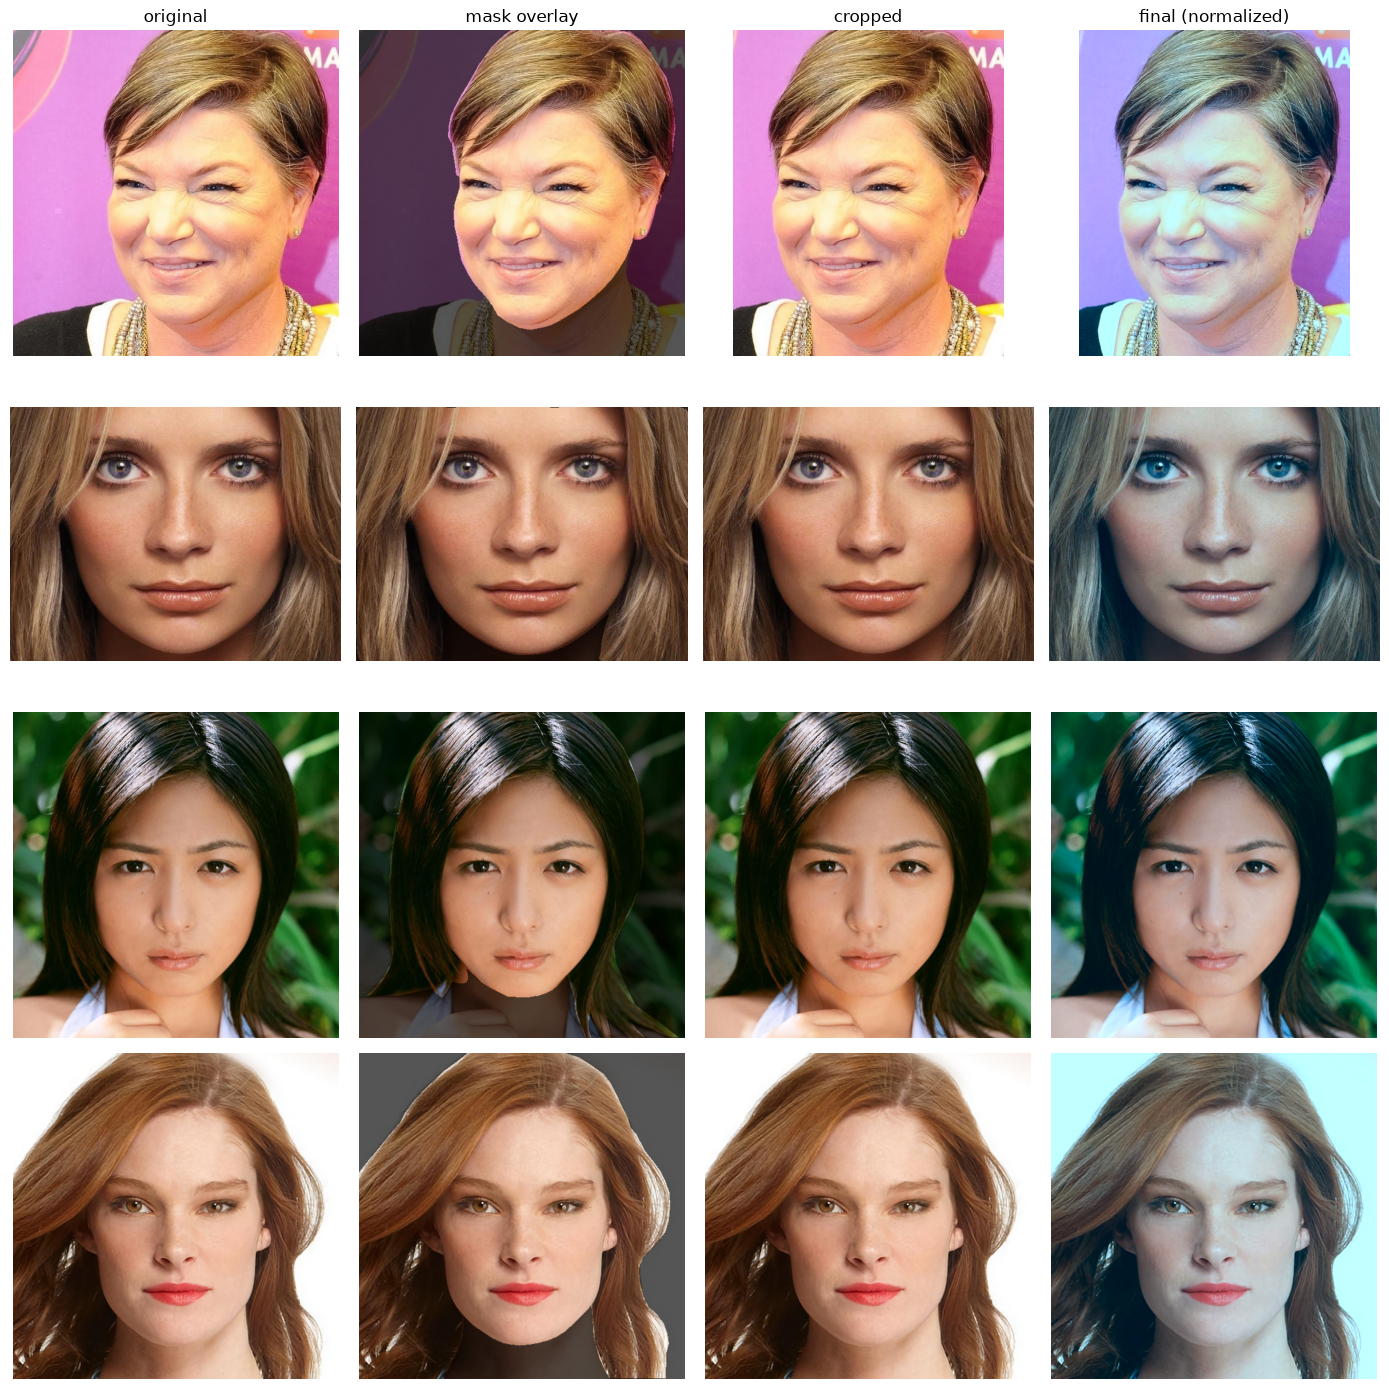

In [4]:
fig, axes = plt.subplots(len(sample), 4, figsize=(14, 3.5 * len(sample)))
col_titles = ["original", "mask overlay", "cropped", "final (normalized)"]

for row_idx, (_, row) in enumerate(sample.iterrows()):
    panels = build_panels(row)
    status = panels[-1]
    for col_idx, panel in enumerate(panels[:-1]):
        ax = axes[row_idx, col_idx]
        ax.imshow(panel)
        ax.axis("off")
        if row_idx == 0:
            ax.set_title(col_titles[col_idx])
    axes[row_idx, 0].set_ylabel(f"{row['class']}/{row['sub_class']}\n({status})", rotation=0, labelpad=60, fontsize=9)

plt.tight_layout()
plt.show()